# RQ6 — Context Generalisation

## Research question

> Do the contextual cues identified in RQ5 transfer to new passwords, or are they password-specific shortcuts?

RQ5 showed that neighbouring movements can strongly predict the W1 true-gate label even when the Current movement is removed. That result is only useful mechanistically if the same contextual structure survives a change in password.

RQ6 therefore freezes the RQ5 historical training data and evaluates it on two different passwords without fitting or tuning on either test set.

### Training and test split

**Training**

- historical W1/W2 context dataset used in RQ5
- the same fixed 13 acoustic features per movement
- the same seven Previous / Current / Next ablations
- logistic regression with fixed hyperparameters

**Inference-only password tests**

- **2748**
- **6542**

Neither password is used for model fitting, scaling decisions, hyperparameter selection or threshold tuning.

### What would count as generalisation?

A contextual cue is more credible as transferable mechanical structure if it remains substantially better than random ranking across both unseen passwords.

A cue is more consistent with a shortcut if it:

- works on the historical password but collapses after a password change;
- transfers to one new password but not another;
- or systematically predicts the old training digit after the true digit changes.

The main statistical unit is the held-out decision/profile. Random 10-way ranking has mean true rank **5.5**.

## 1. Load the frozen RQ5 training representation

In [1]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import shutil
import zipfile
import json

import numpy as np
import pandas as pd
from IPython.display import display

MYDRIVE = Path("/content/drive/MyDrive")
HIST_ROOT = MYDRIVE / "dataset" / "raw" / "historical_data"
PROJECT_ROOT = MYDRIVE / "Padlock_Reproduction_v1"

results_candidates = [
    PROJECT_ROOT / "results",
    PROJECT_ROOT / "Padlock_Reproduction_v1" / "results",
]

RESULTS_ROOT = next(
    (
        p for p in results_candidates
        if (
            p
            / "05_RQ5_Prev_Current_Next"
            / "RQ5_context_table.csv"
        ).exists()
    ),
    None,
)

if RESULTS_ROOT is None:
    raise FileNotFoundError(
        "Could not locate the completed RQ5 results."
    )

TRAIN_TABLE = (
    RESULTS_ROOT
    / "05_RQ5_Prev_Current_Next"
    / "RQ5_context_table.csv"
)

RQ5_SUMMARY = (
    RESULTS_ROOT
    / "05_RQ5_Prev_Current_Next"
    / "RQ5_ablation_summary.csv"
)

RESULT_DIR = (
    RESULTS_ROOT
    / "06_RQ6_Context_Generalisation"
)

CACHE_DIR = (
    RESULTS_ROOT
    / "feature_cache"
)

RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

CACHE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

train_table = pd.read_csv(
    TRAIN_TABLE
)

rq5_summary = pd.read_csv(
    RQ5_SUMMARY
)

print(
    "Historical training candidates:",
    len(train_table),
)

display(
    rq5_summary[
        [
            "dataset",
            "ablation",
            "top1",
            "mean_true_rank",
        ]
    ].round(3)
)

Mounted at /content/drive
Historical training candidates: 1800


,dataset,ablation,top1,mean_true_rank
0,W1,Previous,0.595,1.976
1,W1,Current,0.310,3.631
2,W1,Next,0.262,3.619
3,W1,Previous + Current,0.643,1.917
4,W1,Current + Next,0.381,3.167
5,W1,Previous + Next,0.655,1.988
6,W1,Full,0.690,1.833
7,W2,Previous,0.281,3.625
8,W2,Current,0.448,2.875
9,W2,Next,0.156,4.052


## 2. Reconstruct an unseen password dataset

The helper below performs the same reconstruction for 2748 and 6542: read the run metadata, verify complete 10-candidate cycles, load or rebuild the fixed feature cache, and construct circular Previous / Current / Next context features.

In [2]:
import soundfile as sf

EPS = 1e-12

BASE_FEATURES = [
    "rms",
    "peak",
    "crest",
    "derivative_rms",
    "zcr",
    "spectral_centroid_hz",
    "spectral_bandwidth_hz",
    "rolloff85_hz",
    "spectral_flatness",
    "spectral_entropy",
    "band_0_1k",
    "band_1_4k",
    "band_4_nyquist",
]


def signal_features(x, sr):
    x = np.asarray(
        x,
        dtype=np.float64,
    )

    x = x - np.mean(x)

    rms = np.sqrt(
        np.mean(x ** 2)
    )

    peak = np.max(
        np.abs(x)
    )

    crest = peak / (rms + EPS)

    derivative_rms = np.sqrt(
        np.mean(
            np.diff(x) ** 2
        )
    )

    zcr = np.mean(
        np.signbit(x[:-1])
        != np.signbit(x[1:])
    )

    window = np.hanning(
        len(x)
    )

    power = np.abs(
        np.fft.rfft(
            x * window
        )
    ) ** 2

    freqs = np.fft.rfftfreq(
        len(x),
        d=1.0 / sr,
    )

    total_power = (
        np.sum(power)
        + EPS
    )

    p = power / total_power

    centroid = np.sum(
        freqs * p
    )

    bandwidth = np.sqrt(
        np.sum(
            (
                (freqs - centroid)
                ** 2
            )
            * p
        )
    )

    cumulative = np.cumsum(
        power
    )

    rolloff_idx = np.searchsorted(
        cumulative,
        0.85 * cumulative[-1],
    )

    rolloff_idx = min(
        rolloff_idx,
        len(freqs) - 1,
    )

    rolloff85 = freqs[
        rolloff_idx
    ]

    flatness = (
        np.exp(
            np.mean(
                np.log(
                    power + EPS
                )
            )
        )
        /
        (
            np.mean(power)
            + EPS
        )
    )

    spectral_entropy = (
        -np.sum(
            p
            * np.log(
                p + EPS
            )
        )
        /
        np.log(
            len(p)
        )
    )

    def band_ratio(low, high):
        mask = (
            (freqs >= low)
            &
            (freqs < high)
        )

        return (
            np.sum(
                power[mask]
            )
            /
            total_power
        )

    return np.array([
        rms,
        peak,
        crest,
        derivative_rms,
        zcr,
        centroid,
        bandwidth,
        rolloff85,
        flatness,
        spectral_entropy,
        band_ratio(0, 1000),
        band_ratio(1000, 4000),
        band_ratio(
            4000,
            sr / 2 + 1,
        ),
    ])


def extract_run(run_path):
    run_path = Path(
        run_path
    )

    events = pd.read_csv(
        run_path
        / "events.csv"
    )

    start = int(
        events.loc[
            events["event"]
            == "SCAN_START",
            "aligned_sample_index",
        ].iloc[0]
    )

    end = int(
        events.loc[
            events["event"]
            == "SCAN_END",
            "aligned_sample_index",
        ].iloc[0]
    ) + 1

    audio, sr = sf.read(
        run_path / "audio.wav",
        dtype="float32",
    )

    return signal_features(
        audio[start:end],
        sr,
    )


def prepare_unseen_dataset(
    zip_name,
    password_label,
    cache_name,
):
    drive_zip = (
        HIST_ROOT / zip_name
    )

    if not drive_zip.exists():
        raise FileNotFoundError(
            drive_zip
        )

    local_zip = Path(
        f"/content/{zip_name}"
    )

    extract_root = Path(
        f"/content/RQ6_{password_label}"
    )

    run_dirs = []

    if extract_root.exists():
        run_dirs = sorted(
            [
                p
                for p in extract_root.rglob("run_*")
                if p.is_dir()
            ],
            key=lambda p: int(
                p.name.split("_")[-1]
            ),
        )

    if not run_dirs:
        shutil.copy2(
            drive_zip,
            local_zip,
        )

        if extract_root.exists():
            shutil.rmtree(
                extract_root
            )

        extract_root.mkdir(
            parents=True
        )

        with zipfile.ZipFile(
            local_zip,
            "r",
        ) as z:
            z.extractall(
                extract_root
            )

        run_dirs = sorted(
            [
                p
                for p in extract_root.rglob("run_*")
                if p.is_dir()
            ],
            key=lambda p: int(
                p.name.split("_")[-1]
            ),
        )

    rows = []

    for run_dir in run_dirs:
        with open(
            run_dir / "metadata.json",
            "r",
            encoding="utf-8-sig",
        ) as f:
            meta = json.load(f)

        r = meta["run"]
        c = meta["collection"]

        wheel = int(
            r["wheel_index"]
        )

        if wheel not in [1, 2]:
            continue

        true_key = (
            f"decision_true_w{wheel}"
        )

        before_code = str(
            c["current_code_before"]
        ).zfill(4)

        after_code = str(
            c["current_code_after"]
        ).zfill(4)

        rows.append({
            "dataset": f"W{wheel}",
            "run_id": r["run_id"],
            "run_num": int(
                r["run_id"].split("_")[-1]
            ),
            "wheel": wheel,
            "profile_id": r["profile_id"],
            "decision_id": r["decision_id"],
            "repeat_id": r[
                "decision_repeat_id"
            ],
            "candidate_index": int(
                r[
                    "decision_candidate_index"
                ]
            ),
            "direction": r["direction"],
            "target_digit": int(
                r[
                    "decision_target_digit"
                ]
            ),
            "true_digit": int(
                r[true_key]
            ),
            "is_true_gate": int(
                r[
                    "decision_is_true_gate_movement"
                ]
            ),
            "before_digit": int(
                before_code[
                    wheel - 1
                ]
            ),
            "after_digit": int(
                after_code[
                    wheel - 1
                ]
            ),
            "run_path": str(
                run_dir
            ),
        })

    manifest = (
        pd.DataFrame(rows)
        .sort_values(
            [
                "dataset",
                "run_num",
            ]
        )
        .reset_index(
            drop=True
        )
    )

    audit = (
        manifest
        .groupby(
            [
                "dataset",
                "decision_id",
                "repeat_id",
            ]
        )
        .agg(
            n_candidates=(
                "run_id",
                "size",
            ),
            n_true=(
                "is_true_gate",
                "sum",
            ),
        )
        .reset_index()
    )

    if not (
        (audit["n_candidates"] == 10)
        &
        (audit["n_true"] == 1)
    ).all():
        raise RuntimeError(
            f"{password_label}: invalid decision structure."
        )

    cache_path = (
        CACHE_DIR / cache_name
    )

    expected_keys = np.array([
        f"{row.dataset}::{row.run_id}"
        for row in manifest.itertuples()
    ])

    if cache_path.exists():
        cache = np.load(
            cache_path,
            allow_pickle=False,
        )

        X = cache["X"]

        if "run_keys" in cache.files:
            cache_keys = cache[
                "run_keys"
            ].astype(str)

            if not np.array_equal(
                expected_keys,
                cache_keys,
            ):
                raise RuntimeError(
                    f"{password_label}: cache order mismatch."
                )

    else:
        features = []

        for i, row in manifest.iterrows():
            features.append(
                extract_run(
                    row["run_path"]
                )
            )

            if (i + 1) % 100 == 0:
                print(
                    f"{password_label}: "
                    f"{i + 1}/{len(manifest)}"
                )

        X = np.vstack(
            features
        )

        np.savez_compressed(
            cache_path,
            X=X,
            run_keys=expected_keys.astype(
                "U48"
            ),
            feature_names=np.array(
                BASE_FEATURES,
                dtype="U64",
            ),
        )

    features_df = manifest.copy()

    for j, feature in enumerate(
        BASE_FEATURES
    ):
        features_df[
            f"current_{feature}"
        ] = X[:, j]

    context_rows = []

    for (
        dataset,
        decision_id,
        repeat_id,
    ), group in features_df.groupby(
        [
            "dataset",
            "decision_id",
            "repeat_id",
        ]
    ):
        group = (
            group
            .sort_values(
                "candidate_index"
            )
            .reset_index(
                drop=True
            )
        )

        current_matrix = group[
            [
                f"current_{f}"
                for f in BASE_FEATURES
            ]
        ].to_numpy(
            dtype=float
        )

        previous_matrix = np.roll(
            current_matrix,
            1,
            axis=0,
        )

        next_matrix = np.roll(
            current_matrix,
            -1,
            axis=0,
        )

        for i in range(10):
            row = (
                group.iloc[i]
                .to_dict()
            )

            for j, feature in enumerate(
                BASE_FEATURES
            ):
                row[
                    f"previous_{feature}"
                ] = previous_matrix[
                    i,
                    j,
                ]

                row[
                    f"next_{feature}"
                ] = next_matrix[
                    i,
                    j,
                ]

            context_rows.append(
                row
            )

    context = pd.DataFrame(
        context_rows
    )

    return (
        manifest,
        context,
        audit,
    )

## 3. Evaluate the frozen historical models

In [3]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from scipy.stats import rankdata

previous_features = [
    f"previous_{f}"
    for f in BASE_FEATURES
]

current_features = [
    f"current_{f}"
    for f in BASE_FEATURES
]

next_features = [
    f"next_{f}"
    for f in BASE_FEATURES
]

ablations = {
    "Previous": previous_features,
    "Current": current_features,
    "Next": next_features,
    "Previous + Current": (
        previous_features
        + current_features
    ),
    "Current + Next": (
        current_features
        + next_features
    ),
    "Previous + Next": (
        previous_features
        + next_features
    ),
    "Full": (
        previous_features
        + current_features
        + next_features
    ),
}

ablation_order = list(
    ablations.keys()
)


def evaluate_unseen(
    context,
    password_label,
):
    rows = []

    for dataset_label in [
        "W1",
        "W2",
    ]:
        train = train_table[
            train_table["dataset"]
            == dataset_label
        ].copy()

        test = context[
            context["dataset"]
            == dataset_label
        ].copy()

        for (
            ablation_name,
            features,
        ) in ablations.items():
            model = make_pipeline(
                StandardScaler(),
                LogisticRegression(
                    C=1.0,
                    penalty="l2",
                    solver="liblinear",
                    class_weight="balanced",
                    max_iter=2000,
                    random_state=0,
                ),
            )

            model.fit(
                train[
                    features
                ].to_numpy(
                    dtype=float
                ),
                train[
                    "is_true_gate"
                ].to_numpy(
                    dtype=int
                ),
            )

            for (
                decision_id,
                repeat_id,
            ), decision in test.groupby(
                [
                    "decision_id",
                    "repeat_id",
                ]
            ):
                decision = (
                    decision
                    .sort_values(
                        "candidate_index"
                    )
                )

                scores = model.predict_proba(
                    decision[
                        features
                    ].to_numpy(
                        dtype=float
                    )
                )[:, 1]

                ranks = rankdata(
                    -scores,
                    method="average",
                )

                truth = (
                    decision[
                        "is_true_gate"
                    ].to_numpy(
                        dtype=int
                    )
                    == 1
                )

                true_rank = float(
                    ranks[
                        truth
                    ][0]
                )

                best = int(
                    np.argmax(
                        scores
                    )
                )

                rows.append({
                    "password": password_label,
                    "dataset": dataset_label,
                    "ablation": ablation_name,
                    "decision_id": decision_id,
                    "repeat_id": repeat_id,
                    "true_digit": int(
                        decision.loc[
                            truth,
                            "after_digit",
                        ].iloc[0]
                    ),
                    "predicted_digit": int(
                        decision.iloc[
                            best
                        ]["after_digit"]
                    ),
                    "true_rank": true_rank,
                    "top1": int(
                        true_rank <= 1
                    ),
                    "top2": int(
                        true_rank <= 2
                    ),
                    "top3": int(
                        true_rank <= 3
                    ),
                })

    return pd.DataFrame(
        rows
    )

In [4]:
manifest_2748, context_2748, audit_2748 = prepare_unseen_dataset(
    "code_2748_test_data.zip",
    "2748",
    "RQ6_2748_context_interpretable_v1.npz",
)

manifest_6542, context_6542, audit_6542 = prepare_unseen_dataset(
    "blindvalidation_6542.zip",
    "6542",
    "RQ6_6542_context_interpretable_v1.npz",
)

pred_2748 = evaluate_unseen(
    context_2748,
    "2748",
)

pred_6542 = evaluate_unseen(
    context_6542,
    "6542",
)

pred_2748.to_csv(
    RESULT_DIR / "RQ6_2748_predictions.csv",
    index=False,
)

pred_6542.to_csv(
    RESULT_DIR / "RQ6_6542_predictions.csv",
    index=False,
)

print("2748 predictions:", len(pred_2748))
print("6542 predictions:", len(pred_6542))

2748 predictions: 252
6542 predictions: 336


## 4. Compare the three passwords

In [5]:
def unseen_summary(
    predictions,
    suffix,
):
    rows = []

    for (
        dataset,
        ablation,
    ), group in predictions.groupby(
        [
            "dataset",
            "ablation",
        ]
    ):
        rows.append({
            "dataset": dataset,
            "ablation": ablation,
            f"n_decisions_{suffix}": len(group),
            f"top1_{suffix}": group["top1"].mean(),
            f"top2_{suffix}": group["top2"].mean(),
            f"top3_{suffix}": group["top3"].mean(),
            f"mean_rank_{suffix}": group["true_rank"].mean(),
            f"old_digit_1_prediction_rate_{suffix}": np.mean(
                group["predicted_digit"]
                == 1
            ),
        })

    return pd.DataFrame(
        rows
    )


summary_2748 = unseen_summary(
    pred_2748,
    "2748",
)

summary_6542 = unseen_summary(
    pred_6542,
    "6542",
)

three_way = (
    rq5_summary
    .merge(
        summary_2748,
        on=[
            "dataset",
            "ablation",
        ],
    )
    .merge(
        summary_6542,
        on=[
            "dataset",
            "ablation",
        ],
    )
)

three_way["ablation"] = pd.Categorical(
    three_way["ablation"],
    categories=ablation_order,
    ordered=True,
)

three_way = three_way.sort_values(
    [
        "dataset",
        "ablation",
    ]
)

three_way.to_csv(
    RESULT_DIR / "RQ6_three_password_comparison.csv",
    index=False,
)

display(
    three_way[
        [
            "dataset",
            "ablation",
            "top1",
            "top1_2748",
            "top1_6542",
            "mean_true_rank",
            "mean_rank_2748",
            "mean_rank_6542",
        ]
    ].round(3)
)

,dataset,ablation,top1,top1_2748,top1_6542,mean_true_rank,mean_rank_2748,mean_rank_6542
0,W1,Previous,0.595,0.556,0.417,1.976,2.611,2.958
1,W1,Current,0.310,0.111,0.208,3.631,4.556,3.542
2,W1,Next,0.262,0.111,0.250,3.619,5.056,3.708
3,W1,Previous + Current,0.643,0.389,0.458,1.917,2.444,2.167
4,W1,Current + Next,0.381,0.111,0.250,3.167,4.222,3.667
5,W1,Previous + Next,0.655,0.556,0.500,1.988,2.444,2.792
6,W1,Full,0.690,0.333,0.500,1.833,2.611,2.500
7,W2,Previous,0.281,0.444,0.042,3.625,2.056,7.167
8,W2,Current,0.448,0.278,0.042,2.875,3.889,5.000
9,W2,Next,0.156,0.056,0.042,4.052,4.167,6.625


## 5. Profile-level tests against random ranking

For each unseen password, the two A/B decisions from the same decision/profile are averaged first. The profile mean rank is then tested against random mean rank 5.5.

The one-sided alternative is `mean profile rank < 5.5`. Holm correction is applied across the seven ablations separately within each password × wheel family.

In [6]:
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests


def profile_rank_table(
    predictions,
    password_label,
):
    table = (
        predictions
        .groupby(
            [
                "dataset",
                "ablation",
                "decision_id",
            ]
        )["true_rank"]
        .mean()
        .reset_index()
    )

    table[
        "password"
    ] = password_label

    return table


profile_generalisation = pd.concat(
    [
        profile_rank_table(
            pred_2748,
            "2748",
        ),
        profile_rank_table(
            pred_6542,
            "6542",
        ),
    ],
    ignore_index=True,
)

test_tables = []

for (
    password,
    dataset,
), group in profile_generalisation.groupby(
    [
        "password",
        "dataset",
    ]
):
    rows = []

    for ablation in ablation_order:
        ranks = group.loc[
            group["ablation"]
            == ablation,
            "true_rank",
        ].to_numpy(
            dtype=float
        )

        stat, p_value = wilcoxon(
            ranks - 5.5,
            alternative="less",
            method="auto",
        )

        rows.append({
            "password": password,
            "dataset": dataset,
            "ablation": ablation,
            "n_profiles": len(ranks),
            "mean_profile_rank": ranks.mean(),
            "median_profile_rank": np.median(
                ranks
            ),
            "p_raw": p_value,
        })

    local = pd.DataFrame(
        rows
    )

    local["p_holm"] = multipletests(
        local["p_raw"],
        method="holm",
    )[1]

    test_tables.append(
        local
    )


profile_tests = pd.concat(
    test_tables,
    ignore_index=True,
)

profile_tests.to_csv(
    RESULT_DIR / "RQ6_profile_level_tests.csv",
    index=False,
)

display(
    profile_tests.round(4)
)

,password,dataset,ablation,n_profiles,mean_profile_rank,median_profile_rank,p_raw,p_holm
0,2748,W1,Previous,9,2.6111,1.50,0.0078,0.0312
1,2748,W1,Current,9,4.5556,4.00,0.1484,0.2969
2,2748,W1,Next,9,5.0556,5.00,0.3086,0.3086
3,2748,W1,Previous + Current,9,2.4444,2.00,0.0020,0.0137
4,2748,W1,Current + Next,9,4.2222,4.00,0.0156,0.0469
5,2748,W1,Previous + Next,9,2.4444,1.50,0.0020,0.0137
6,2748,W1,Full,9,2.6111,2.00,0.0039,0.0195
7,2748,W2,Previous,9,2.0556,1.50,0.0020,0.0137
8,2748,W2,Current,9,3.8889,5.00,0.0469,0.0547
9,2748,W2,Next,9,4.1667,4.00,0.0156,0.0469


## 6. Main figures

The figures answer three different generalisation questions: whether performance survives the password change, whether the unseen profile ranks remain better than random, and whether a failed transfer shows systematic bias toward the historical training digit. Figure titles are left to the report caption.

In [7]:
import matplotlib.pyplot as plt

DARK_BLUE = "#315B7D"
MID_BLUE = "#6F8FA8"
LIGHT_BLUE = "#AFC5D5"
MID_GREY = "#9EA5AA"
DARK_GREY = "#596168"

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def save_figure(fig, stem):
    fig.savefig(
        RESULT_DIR / f"{stem}.png",
        dpi=300,
        bbox_inches="tight",
    )
    fig.savefig(
        RESULT_DIR / f"{stem}.pdf",
        bbox_inches="tight",
    )

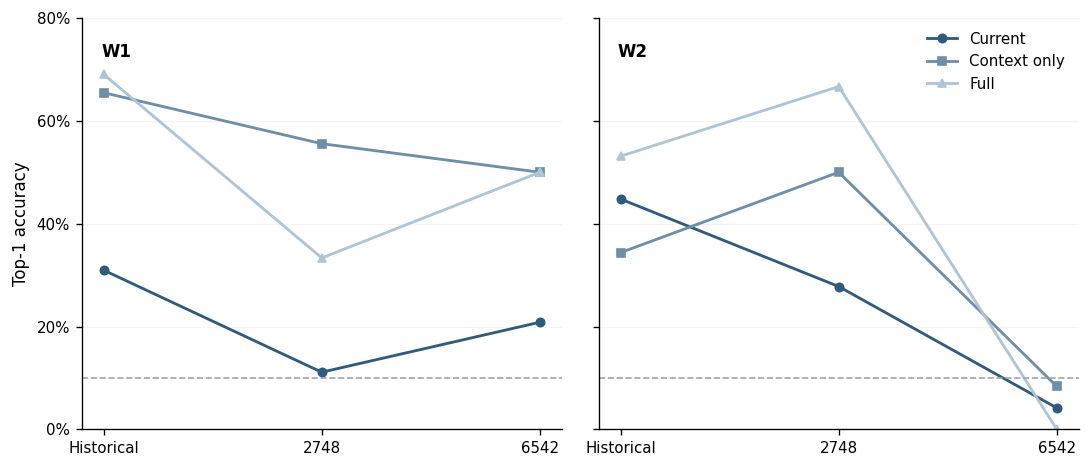

In [8]:
# Figure 1 — transfer of key representations across passwords

passwords = [
    "Historical",
    "2748",
    "6542",
]

x = np.arange(
    len(passwords)
)

key_models = [
    "Current",
    "Previous + Next",
    "Full",
]

model_labels = {
    "Current": "Current",
    "Previous + Next": "Context only",
    "Full": "Full",
}

colors = {
    "Current": DARK_BLUE,
    "Previous + Next": MID_BLUE,
    "Full": LIGHT_BLUE,
}

markers = {
    "Current": "o",
    "Previous + Next": "s",
    "Full": "^",
}

fig, axes = plt.subplots(
    1,
    2,
    figsize=(9.2, 4.0),
    sharey=True,
)

transfer_rows = []

for ax, dataset in zip(
    axes,
    ["W1", "W2"],
):
    table = (
        three_way[
            three_way["dataset"]
            == dataset
        ]
        .set_index(
            "ablation"
        )
    )

    for model in key_models:
        row = table.loc[
            model
        ]

        values = np.array([
            row["top1"],
            row["top1_2748"],
            row["top1_6542"],
        ])

        ax.plot(
            x,
            100 * values,
            marker=markers[model],
            markersize=5,
            linewidth=1.7,
            color=colors[model],
            label=model_labels[model],
        )

        for password, value in zip(
            passwords,
            values,
        ):
            transfer_rows.append({
                "dataset": dataset,
                "model": model,
                "password": password,
                "top1": float(value),
            })

    ax.axhline(
        10,
        linestyle="--",
        linewidth=1,
        color=MID_GREY,
    )

    ax.text(
        0.04,
        0.94,
        dataset,
        transform=ax.transAxes,
        fontsize=10,
        fontweight="bold",
        va="top",
    )

    ax.set_xticks(
        x
    )

    ax.set_xticklabels(
        passwords
    )

    ax.set_ylim(
        0,
        80,
    )

    ax.set_yticks(
        np.arange(
            0,
            81,
            20,
        )
    )

    ax.set_yticklabels([
        f"{v}%"
        for v in np.arange(
            0,
            81,
            20,
        )
    ])

    ax.grid(
        axis="y",
        alpha=0.13,
    )

axes[0].set_ylabel(
    "Top-1 accuracy"
)

axes[1].legend(
    frameon=False,
    loc="upper right",
)

fig.tight_layout()

save_figure(
    fig,
    "RQ6_Fig1_password_transfer",
)

pd.DataFrame(
    transfer_rows
).to_csv(
    RESULT_DIR / "RQ6_key_transfer_summary.csv",
    index=False,
)

plt.show()

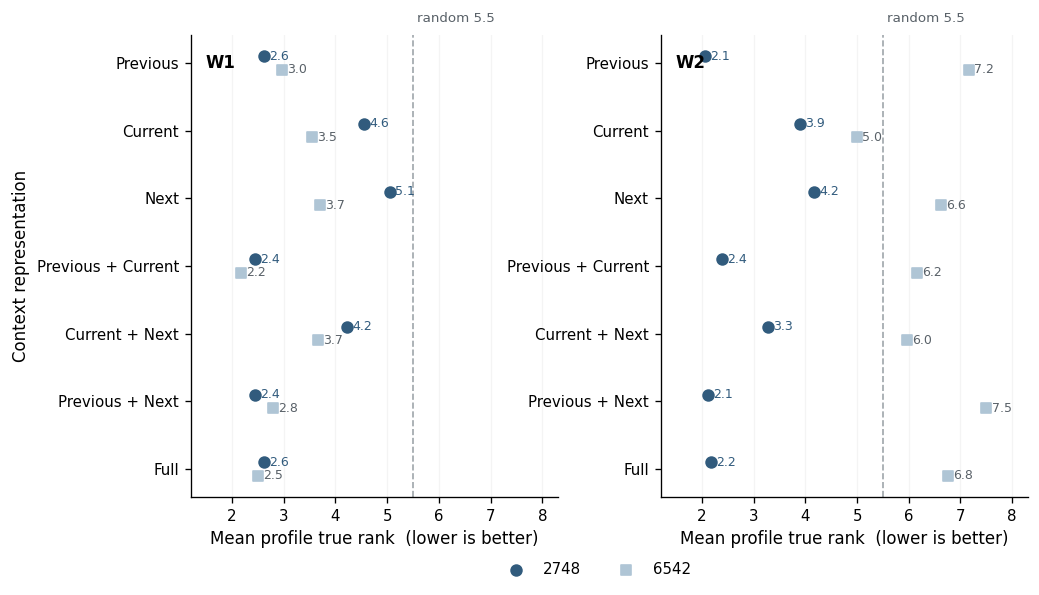

In [9]:
# Figure 2 — mean profile rank on the two unseen passwords

fig, axes = plt.subplots(
    1,
    2,
    figsize=(9.0, 5.2),
    sharex=True,
)

y = np.arange(
    len(ablation_order)
)

offsets = {
    "2748": -0.10,
    "6542": 0.10,
}

password_colors = {
    "2748": DARK_BLUE,
    "6542": LIGHT_BLUE,
}

password_markers = {
    "2748": "o",
    "6542": "s",
}

for ax, dataset in zip(
    axes,
    ["W1", "W2"],
):
    sub = profile_tests[
        profile_tests["dataset"]
        == dataset
    ]

    for password in [
        "2748",
        "6542",
    ]:
        password_sub = (
            sub[
                sub["password"]
                .astype(str)
                == password
            ]
            .set_index(
                "ablation"
            )
            .reindex(
                ablation_order
            )
        )

        ax.scatter(
            password_sub[
                "mean_profile_rank"
            ],
            y + offsets[password],
            s=42,
            marker=password_markers[
                password
            ],
            color=password_colors[
                password
            ],
            label=password,
            zorder=3,
        )

        for yi, row in enumerate(
            password_sub.itertuples()
        ):
            value = float(
                row.mean_profile_rank
            )

            ax.text(
                value + 0.10,
                yi + offsets[password],
                f"{value:.1f}",
                va="center",
                fontsize=7.5,
                color=(
                    DARK_BLUE
                    if password
                    == "2748"
                    else DARK_GREY
                ),
            )

    ax.axvline(
        5.5,
        linestyle="--",
        linewidth=1,
        color=MID_GREY,
    )

    ax.text(
        0.04,
        0.96,
        dataset,
        transform=ax.transAxes,
        fontsize=10,
        fontweight="bold",
        va="top",
    )

    ax.set_yticks(
        y
    )

    ax.set_yticklabels(
        ablation_order
    )

    ax.invert_yaxis()

    ax.set_xlim(
        1.2,
        8.3,
    )

    ax.text(
        5.58,
        -0.56,
        "random 5.5",
        fontsize=8,
        color=DARK_GREY,
        va="bottom",
    )

    ax.set_xlabel(
        "Mean profile true rank  (lower is better)"
    )

    ax.grid(
        axis="x",
        alpha=0.13,
    )

axes[0].set_ylabel(
    "Context representation"
)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    frameon=False,
    ncol=2,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.01),
)

fig.subplots_adjust(
    bottom=0.14,
    wspace=0.28,
)

save_figure(
    fig,
    "RQ6_Fig2_unseen_profile_rank",
)

plt.show()

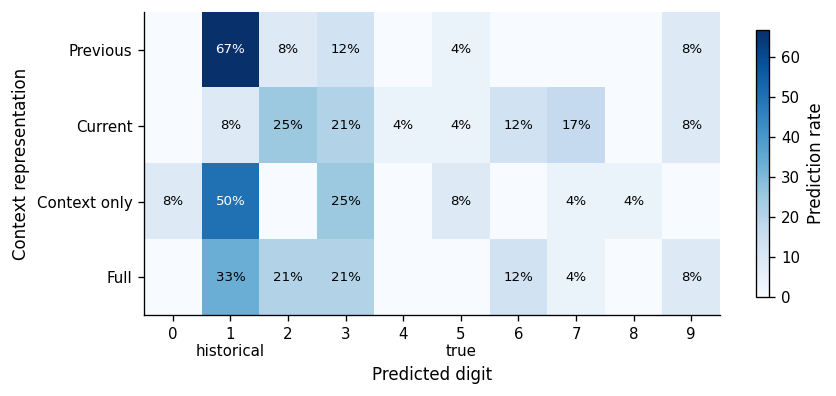

In [10]:
# Figure 3 — W2 prediction distribution on password 6542

bias_models = [
    "Previous",
    "Current",
    "Previous + Next",
    "Full",
]

bias_matrix = []

for model in bias_models:
    group = pred_6542[
        (
            pred_6542[
                "dataset"
            ]
            == "W2"
        )
        &
        (
            pred_6542[
                "ablation"
            ]
            == model
        )
    ]

    rates = (
        group[
            "predicted_digit"
        ]
        .value_counts(
            normalize=True
        )
        .reindex(
            range(10),
            fill_value=0.0,
        )
        .to_numpy(
            dtype=float
        )
    )

    bias_matrix.append(
        rates
    )

bias_matrix = np.vstack(
    bias_matrix
)

bias_rows = []

for model, rates in zip(
    bias_models,
    bias_matrix,
):
    for digit, rate in enumerate(
        rates
    ):
        bias_rows.append({
            "dataset": "W2",
            "password": "6542",
            "ablation": model,
            "predicted_digit": digit,
            "prediction_rate": float(rate),
        })

pd.DataFrame(
    bias_rows
).to_csv(
    RESULT_DIR / "RQ6_W2_6542_prediction_bias.csv",
    index=False,
)

fig, ax = plt.subplots(
    figsize=(7.4, 3.4)
)

image = ax.imshow(
    100 * bias_matrix,
    aspect="auto",
    cmap="Blues",
    vmin=0,
    vmax=max(
        50,
        float(
            np.max(
                100 * bias_matrix
            )
        ),
    ),
)

ax.set_xticks(
    np.arange(10)
)

ax.set_xticklabels([
    "0",
    "1\nhistorical",
    "2",
    "3",
    "4",
    "5\ntrue",
    "6",
    "7",
    "8",
    "9",
])

ax.set_yticks(
    np.arange(
        len(bias_models)
    )
)

ax.set_yticklabels([
    "Previous",
    "Current",
    "Context only",
    "Full",
])

threshold = (
    0.55
    * np.max(
        100 * bias_matrix
    )
)

for i in range(
    bias_matrix.shape[0]
):
    for j in range(
        bias_matrix.shape[1]
    ):
        value = (
            100
            * bias_matrix[i, j]
        )

        if value > 0:
            ax.text(
                j,
                i,
                f"{value:.0f}%",
                ha="center",
                va="center",
                fontsize=8,
                color=(
                    "white"
                    if value
                    >= threshold
                    else "black"
                ),
            )

ax.set_xlabel(
    "Predicted digit"
)

ax.set_ylabel(
    "Context representation"
)

cbar = fig.colorbar(
    image,
    ax=ax,
    shrink=0.88,
)

cbar.set_label(
    "Prediction rate"
)

fig.tight_layout()

save_figure(
    fig,
    "RQ6_Fig3_W2_6542_prediction_bias",
)

plt.show()

## 7. Tables and result record

In [11]:
key_models = [
    "Current",
    "Previous + Next",
    "Full",
]

model_labels = {
    "Current": "Current",
    "Previous + Next": "Context only",
    "Full": "Full",
}

key_transfer = three_way[
    three_way["ablation"]
    .isin(
        key_models
    )
].copy()

key_transfer["Model"] = (
    key_transfer["ablation"]
    .map(
        model_labels
    )
)

key_transfer["Historical Top-1"] = (
    100
    * key_transfer["top1"]
).map(
    lambda x: f"{x:.1f}%"
)

key_transfer["2748 Top-1"] = (
    100
    * key_transfer["top1_2748"]
).map(
    lambda x: f"{x:.1f}%"
)

key_transfer["6542 Top-1"] = (
    100
    * key_transfer["top1_6542"]
).map(
    lambda x: f"{x:.1f}%"
)

key_transfer[
    "Historical mean rank"
] = key_transfer[
    "mean_true_rank"
].map(
    lambda x: f"{x:.2f}"
)

key_transfer[
    "2748 mean rank"
] = key_transfer[
    "mean_rank_2748"
].map(
    lambda x: f"{x:.2f}"
)

key_transfer[
    "6542 mean rank"
] = key_transfer[
    "mean_rank_6542"
].map(
    lambda x: f"{x:.2f}"
)

table1 = key_transfer[
    [
        "dataset",
        "Model",
        "Historical Top-1",
        "2748 Top-1",
        "6542 Top-1",
        "Historical mean rank",
        "2748 mean rank",
        "6542 mean rank",
    ]
].rename(
    columns={
        "dataset": "Wheel",
    }
)

table1.to_csv(
    RESULT_DIR / "RQ6_Table1_key_transfer.csv",
    index=False,
)

with open(
    RESULT_DIR / "RQ6_Table1_key_transfer.tex",
    "w",
    encoding="utf-8",
) as f:
    f.write(
        table1.to_latex(
            index=False,
            escape=True,
        )
    )


table2 = profile_tests.copy()

table2[
    "Mean profile rank"
] = table2[
    "mean_profile_rank"
].map(
    lambda x: f"{x:.2f}"
)

table2[
    "Median profile rank"
] = table2[
    "median_profile_rank"
].map(
    lambda x: f"{x:.2f}"
)

table2[
    "Holm p"
] = table2[
    "p_holm"
].map(
    lambda x: (
        "<0.001"
        if x < 0.001
        else f"{x:.3f}"
    )
)

table2 = table2[
    [
        "password",
        "dataset",
        "ablation",
        "n_profiles",
        "Mean profile rank",
        "Median profile rank",
        "Holm p",
    ]
].rename(
    columns={
        "password": "Password",
        "dataset": "Wheel",
        "ablation": "Ablation",
        "n_profiles": "N profiles",
    }
)

table2.to_csv(
    RESULT_DIR / "RQ6_Table2_profile_tests.csv",
    index=False,
)

with open(
    RESULT_DIR / "RQ6_Table2_profile_tests.tex",
    "w",
    encoding="utf-8",
) as f:
    f.write(
        table2.to_latex(
            index=False,
            escape=True,
        )
    )

display(table1)
display(table2)

,Wheel,Model,Historical Top-1,2748 Top-1,6542 Top-1,Historical mean rank,2748 mean rank,6542 mean rank
1,W1,Current,31.0%,11.1%,20.8%,3.63,4.56,3.54
5,W1,Context only,65.5%,55.6%,50.0%,1.99,2.44,2.79
6,W1,Full,69.0%,33.3%,50.0%,1.83,2.61,2.50
8,W2,Current,44.8%,27.8%,4.2%,2.88,3.89,5.00
12,W2,Context only,34.4%,50.0%,8.3%,3.43,2.11,7.50
13,W2,Full,53.1%,66.7%,0.0%,2.45,2.17,6.75


,Password,Wheel,Ablation,N profiles,Mean profile rank,Median profile rank,Holm p
0,2748,W1,Previous,9,2.61,1.50,0.031
1,2748,W1,Current,9,4.56,4.00,0.297
2,2748,W1,Next,9,5.06,5.00,0.309
3,2748,W1,Previous + Current,9,2.44,2.00,0.014
4,2748,W1,Current + Next,9,4.22,4.00,0.047
5,2748,W1,Previous + Next,9,2.44,1.50,0.014
6,2748,W1,Full,9,2.61,2.00,0.020
7,2748,W2,Previous,9,2.06,1.50,0.014
8,2748,W2,Current,9,3.89,5.00,0.055
9,2748,W2,Next,9,4.17,4.00,0.047


In [12]:
w1 = (
    three_way[
        three_way["dataset"]
        == "W1"
    ]
    .set_index(
        "ablation"
    )
)

w2 = (
    three_way[
        three_way["dataset"]
        == "W2"
    ]
    .set_index(
        "ablation"
    )
)

bias_models = [
    "Previous",
    "Current",
    "Previous + Next",
    "Full",
]

rq6_conclusion = {
    "research_question": (
        "Are contextual cues stable true-gate information or password-dependent shortcuts?"
    ),
    "analysis_type": (
        "Controlled confirmatory generalisation test"
    ),
    "training_scope": (
        "Historical W1/W2 data only. Neither 2748 nor 6542 was used for fitting or tuning."
    ),
    "W1": {
        "current_top1": {
            "historical": float(
                w1.loc[
                    "Current",
                    "top1",
                ]
            ),
            "2748": float(
                w1.loc[
                    "Current",
                    "top1_2748",
                ]
            ),
            "6542": float(
                w1.loc[
                    "Current",
                    "top1_6542",
                ]
            ),
        },
        "context_only_top1": {
            "historical": float(
                w1.loc[
                    "Previous + Next",
                    "top1",
                ]
            ),
            "2748": float(
                w1.loc[
                    "Previous + Next",
                    "top1_2748",
                ]
            ),
            "6542": float(
                w1.loc[
                    "Previous + Next",
                    "top1_6542",
                ]
            ),
        },
        "full_top1": {
            "historical": float(
                w1.loc[
                    "Full",
                    "top1",
                ]
            ),
            "2748": float(
                w1.loc[
                    "Full",
                    "top1_2748",
                ]
            ),
            "6542": float(
                w1.loc[
                    "Full",
                    "top1_6542",
                ]
            ),
        },
    },
    "W2": {
        "current_top1": {
            "historical": float(
                w2.loc[
                    "Current",
                    "top1",
                ]
            ),
            "2748": float(
                w2.loc[
                    "Current",
                    "top1_2748",
                ]
            ),
            "6542": float(
                w2.loc[
                    "Current",
                    "top1_6542",
                ]
            ),
        },
        "context_only_top1": {
            "historical": float(
                w2.loc[
                    "Previous + Next",
                    "top1",
                ]
            ),
            "2748": float(
                w2.loc[
                    "Previous + Next",
                    "top1_2748",
                ]
            ),
            "6542": float(
                w2.loc[
                    "Previous + Next",
                    "top1_6542",
                ]
            ),
        },
        "full_top1": {
            "historical": float(
                w2.loc[
                    "Full",
                    "top1",
                ]
            ),
            "2748": float(
                w2.loc[
                    "Full",
                    "top1_2748",
                ]
            ),
            "6542": float(
                w2.loc[
                    "Full",
                    "top1_6542",
                ]
            ),
        },
        "6542_old_digit_1_bias": {
            model: float(
                np.mean(
                    pred_6542.loc[
                        (
                            pred_6542[
                                "dataset"
                            ]
                            == "W2"
                        )
                        &
                        (
                            pred_6542[
                                "ablation"
                            ]
                            == model
                        ),
                        "predicted_digit",
                    ]
                    == 1
                )
            )
            for model in bias_models
        },
    },
    "profile_level_tests": (
        profile_tests.to_dict(
            orient="records"
        )
    ),
    "interpretation": (
        "Contextual information contains a mixture of transferable mechanical structure "
        "and password-dependent shortcut information. W1 transfers meaningfully to both "
        "unseen passwords: context-only Top-1 remains 55.6% on 2748 and 50.0% on 6542. "
        "W2 is highly password-dependent: context-only rises to 50.0% on 2748 but collapses "
        "to 8.3% on 6542, while Full falls from 66.7% to 0.0%. On 6542, several W2 "
        "representations also over-predict the historical training digit 1, supporting "
        "shortcut learning rather than a stable universal true-gate cue."
    ),
    "limitation": (
        "This is a frozen 13-feature interpretable replay rather than an exact reproduction "
        "of the original historical high-accuracy context model. Password order is not a "
        "time-series variable; the two unseen passwords are independent transfer tests."
    ),
    "next_step": (
        "RQ7 tests whether replacing absolute acoustic identity with within-scan relative "
        "representation reduces this password-specific shortcut dependence."
    ),
}

with open(
    RESULT_DIR / "RQ6_conclusion.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        rq6_conclusion,
        f,
        indent=2,
    )

run_info = {
    "notebook": "06_RQ6_Context_Generalisation.ipynb",
    "historical_training_source": (
        "results/05_RQ5_Prev_Current_Next/RQ5_context_table.csv"
    ),
    "unseen_passwords": [
        "2748",
        "6542",
    ],
    "unseen_raw_sources": [
        "dataset/raw/historical_data/code_2748_test_data.zip",
        "dataset/raw/historical_data/blindvalidation_6542.zip",
    ],
    "feature_count_per_movement": 13,
    "ablations": ablation_order,
    "classifier": {
        "type": "LogisticRegression",
        "C": 1.0,
        "solver": "liblinear",
        "class_weight": "balanced",
        "random_state": 0,
    },
    "fitting_rule": (
        "Fit on historical W1/W2 candidates only. "
        "2748 and 6542 are inference-only."
    ),
    "profile_test": (
        "For each unseen password × wheel × ablation, mean true rank is computed per "
        "decision/profile and tested against random mean rank 5.5 with a one-sided "
        "Wilcoxon test; Holm correction is applied across seven ablations within each "
        "password × wheel family."
    ),
}

with open(
    RESULT_DIR / "RQ6_run_info.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        run_info,
        f,
        indent=2,
    )

print(
    json.dumps(
        rq6_conclusion,
        indent=2,
    )
)

print("\nSaved outputs:")
for path in sorted(
    RESULT_DIR.glob(
        "RQ6_*"
    )
):
    print(
        " -",
        path.name,
    )

{
  "research_question": "Are contextual cues stable true-gate information or password-dependent shortcuts?",
  "analysis_type": "Controlled confirmatory generalisation test",
  "training_scope": "Historical W1/W2 data only. Neither 2748 nor 6542 was used for fitting or tuning.",
  "W1": {
    "current_top1": {
      "historical": 0.3095238095238095,
      "2748": 0.1111111111111111,
      "6542": 0.20833333333333334
    },
    "context_only_top1": {
      "historical": 0.6547619047619048,
      "2748": 0.5555555555555556,
      "6542": 0.5
    },
    "full_top1": {
      "historical": 0.6904761904761905,
      "2748": 0.3333333333333333,
      "6542": 0.5
    }
  },
  "W2": {
    "current_top1": {
      "historical": 0.4479166666666667,
      "2748": 0.2777777777777778,
      "6542": 0.041666666666666664
    },
    "context_only_top1": {
      "historical": 0.34375,
      "2748": 0.5,
      "6542": 0.08333333333333333
    },
    "full_top1": {
      "historical": 0.53125,
      "2748"